# Wind profile 2D

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Changing surface roughness $z_0$

C:\Users\allpe\AppData\Local\Temp\ipykernel_10248\3057566121.py:14: RuntimeWarning: divide by zero encountered in divide
  return np.sqrt((2/3)*k) / U(z, u_star, z0)


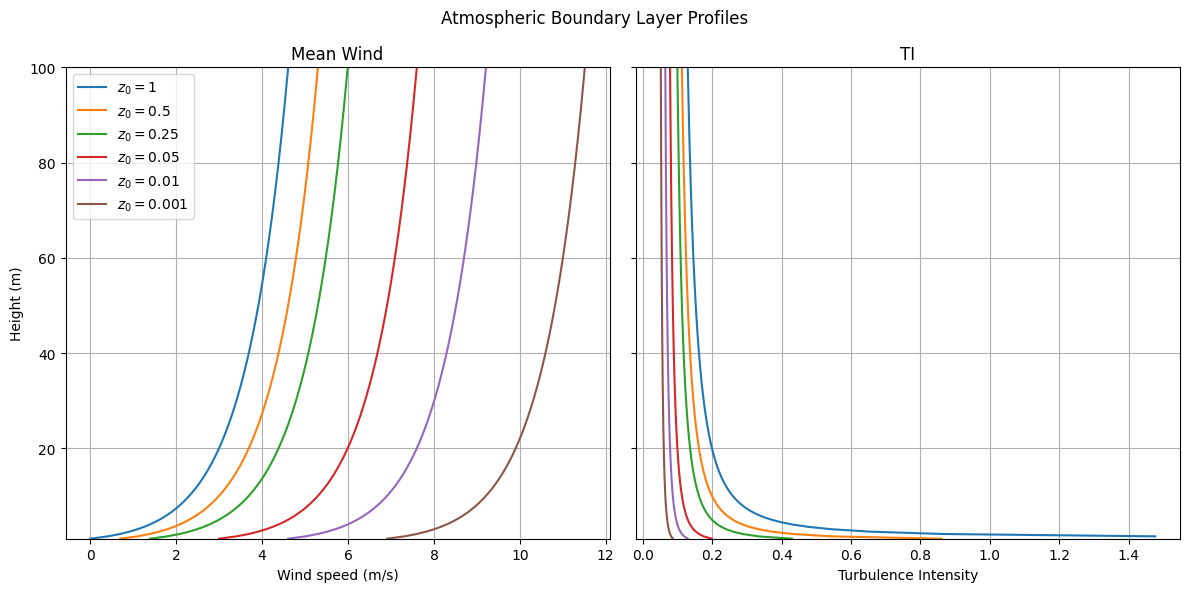

In [180]:
# constants
kappa = 0.4
Cmu = 0.09
u_star = 0.4

# surface roughness
z0 = [1,0.5,0.25,0.05,0.01,0.001]

def U(z, u_star, z0):
    return (u_star/kappa) * np.log(z/z0)

def TI(z, u_star, z0):
    k = (u_star**2)/np.sqrt(Cmu)
    return np.sqrt((2/3)*k) / U(z, u_star, z0)

z = np.linspace(1,100,200)

fig, ax = plt.subplots(1,2,figsize=(12,6),sharey=True)

for rough in z0:
    ax[0].plot(U(z,u_star,rough), z, label=f'$z_0={rough}$')
    ax[1].plot(TI(z,u_star,rough), z)

ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")

ax[1].set_xlabel("Turbulence Intensity")
ax[1].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1,100)

ax[0].legend()

plt.suptitle("Atmospheric Boundary Layer Profiles")

plt.tight_layout()
plt.show()

## Wind profile over changing surface roughness $z_{0,1} \rightarrow z_{0,2}$

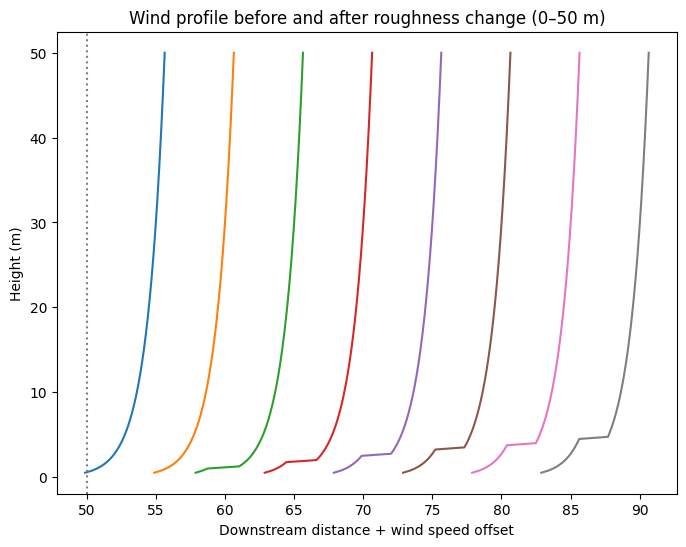

In [181]:
# constants
kappa = 0.4
ustar = 0.5

# roughness lengths
z0_up = 0.01
z0_down = 0.05

# vertical grid (0–50 m)
z = np.linspace(0.5,50,200)

# domain
x_domain = 100
x_change = x_domain/2

# locations of profiles
x_positions = [x_change-5, x_change, x_change+5,x_change+10, x_change+15, x_change+20, x_change+25, x_change+30]

# internal boundary layer growth
def ibl_height(x):
    
    dx = x - x_change
    
    if dx <= 0:
        return 0
    else:
        return 0.3 * dx**0.8


# wind profile
def wind_profile(z,x):

    delta = ibl_height(x)
    U = np.zeros_like(z)

    for i in range(len(z)):

        # upstream of roughness change
        if x <= x_change:
            U[i] = (ustar/kappa)*np.log(z[i]/z0_up)

        # downstream region
        else:
            if z[i] < delta:
                U[i] = (ustar/kappa)*np.log(z[i]/z0_down)
            else:
                U[i] = (ustar/kappa)*np.log(z[i]/z0_up)

    return U


plt.figure(figsize=(8,6))

for x in x_positions:

    U = wind_profile(z,x)

    # shift profile to x location
    plt.plot(x + U, z)


# internal boundary layer
x_line = np.linspace(0,x_domain,200)
ibl = [ibl_height(x) for x in x_line]

#plt.plot(x_line, ibl, 'k--', label="Internal BL")

# mark roughness change
plt.axvline(x_change, color='gray', linestyle=':')

plt.xlabel("Downstream distance + wind speed offset")
plt.ylabel("Height (m)")
plt.title("Wind profile before and after roughness change (0–50 m)")
#plt.legend()

plt.show()

## Changing friction velocity $u^*$

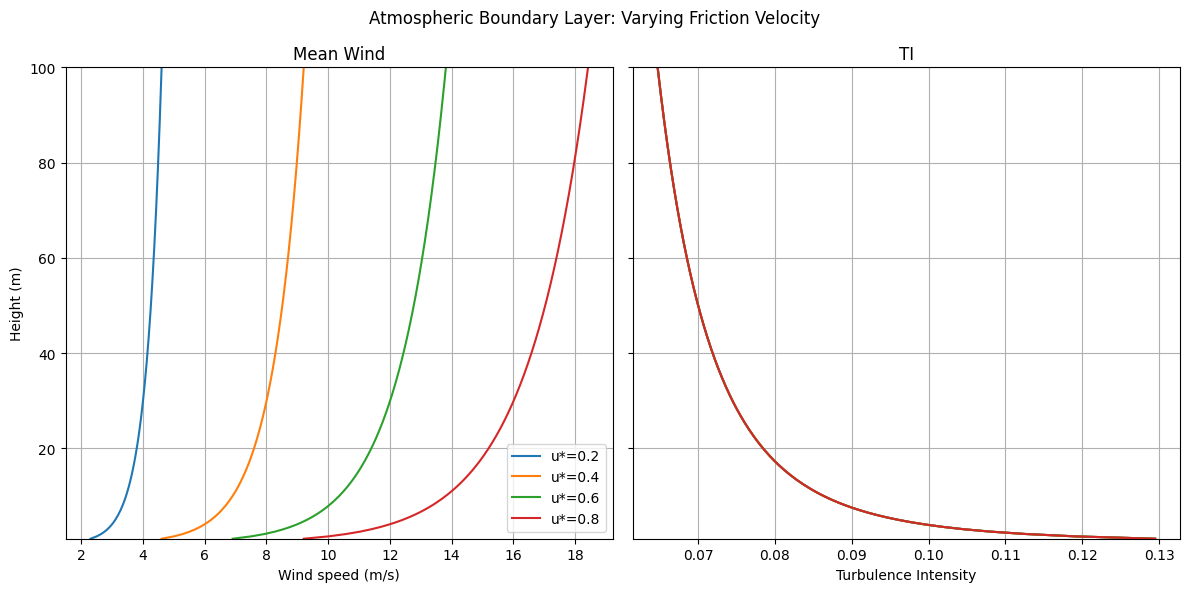

In [182]:
# constants
kappa = 0.4
Cmu = 0.09
z0 = 0.01  # fixed roughness

def U(z, u_star):
    return (u_star/kappa) * np.log(z/z0)

def TI(z, u_star):
    k = u_star**2 / np.sqrt(Cmu)
    return np.sqrt(2/3 * k) / U(z, u_star)

z = np.linspace(1,100,200)

u_star_values = [0.2, 0.4, 0.6, 0.8]

fig, ax = plt.subplots(1,2,figsize=(12,6), sharey=True)

for u_star in u_star_values:
    ax[0].plot(U(z,u_star), z, label=f'u*={u_star}')
    ax[1].plot(TI(z,u_star), z)

ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")
ax[0].legend()

ax[1].set_xlabel("Turbulence Intensity")
ax[1].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1,100)

plt.suptitle("Atmospheric Boundary Layer: Varying Friction Velocity")
plt.tight_layout()
plt.show()

## Stability term $\psi(z,L)$

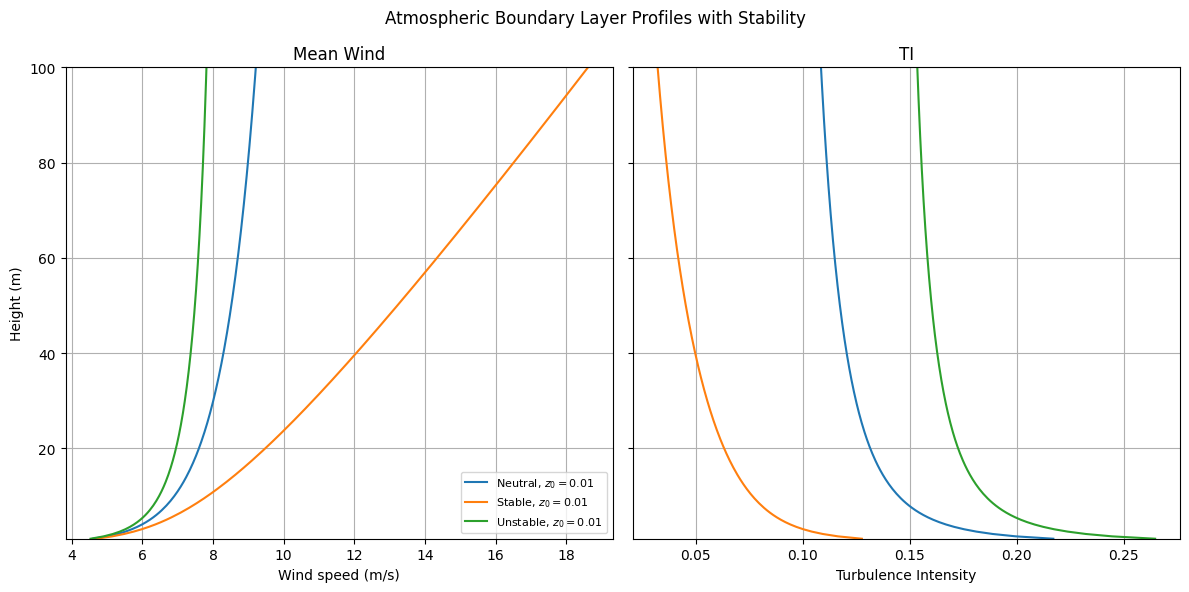

In [183]:
# constants
kappa = 0.4
u_star = 0.4
z0_list = [0.01]  # multiple roughness values
L = 50  # Obukhov length (positive = stable, negative = unstable)

def psi(z, L, stability):
    if stability == 0:  # neutral
        return 0

    if stability == 1:  # stable
        L = abs(L)
        return -4.7 * (z / L)

    if stability == 2:  # unstable 
        L = -abs(L)
        return (1 - 16 * (z / L))**0.25 - 1

def U(z, u_star, z0, L, stability):
    return (u_star / kappa) * (np.log(z / z0) - psi(z, L, stability))

# stability-dependent turbulence
def sigma_u(u_star, z, L, stability):
    if stability == 0:  # neutral
        return 2.5 * u_star

    if stability == 1:  # stable → less turbulence
        return 1.5 * u_star

    if stability == 2:  # unstable → more turbulence
        return 3.0 * u_star

def TI(z, u_star, z0, L, stability):
    return sigma_u(u_star, z, L, stability) / U(z, u_star, z0, L, stability)


# height range
z = np.linspace(1, 100, 200)

fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

stabilities = {
    0: "Neutral",
    1: "Stable",
    2: "Unstable"
}

for stability, label in stabilities.items():
    for z0 in z0_list:
        U_vals = U(z, u_star, z0, L, stability)
        TI_vals = TI(z, u_star, z0, L, stability)

        ax[0].plot(U_vals, z, label=f'{label}, $z_0={z0}$')
        ax[1].plot(TI_vals, z)

# labels
ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")

ax[1].set_xlabel("Turbulence Intensity")
ax[1].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1, 100)

ax[0].legend(fontsize=8)

plt.suptitle("Atmospheric Boundary Layer Profiles with Stability")

plt.tight_layout()
plt.show()

## Varying Monin Obukhov length $L$ in the stability function

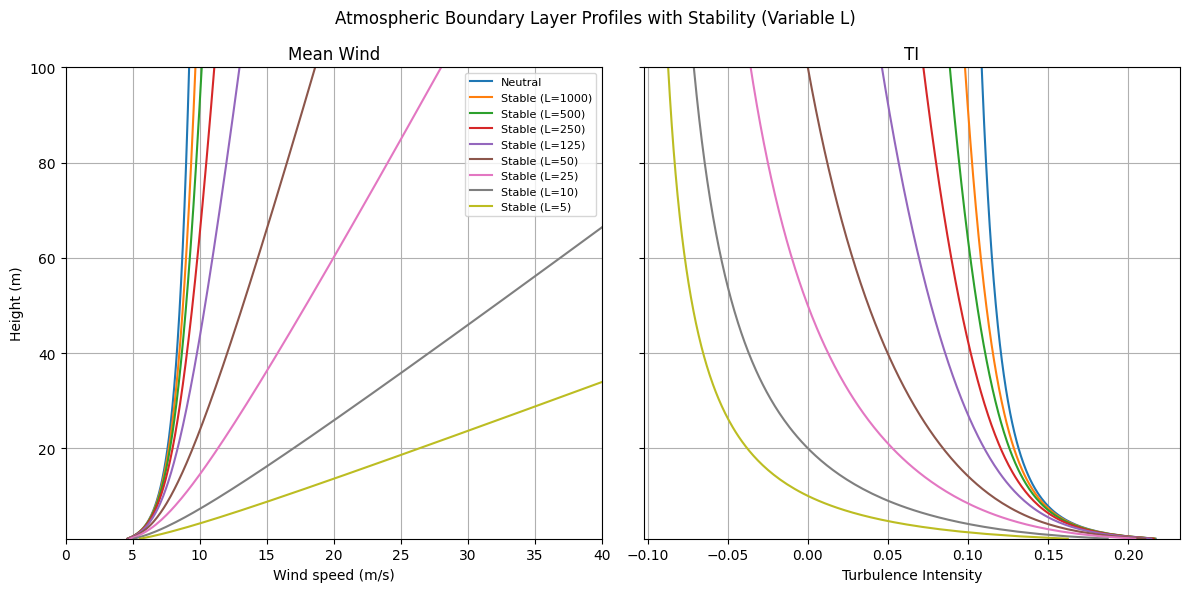

In [184]:
# constants
kappa = 0.4
u_star = 0.4
z0 = 0.01  # roughness values

# Obukhov lengths (stable → neutral → unstable)
L_values = [np.inf, 1000, 500, 250, 125, 50, 25, 10, 5]

# height range
z = np.linspace(1, 100, 200)

# stability correction function (Businger-Dyer)
def psi(z, L):
    if np.isinf(L):  # neutral
        return 0

    if L > 0:  # stable
        return -4.7 * (z / L)

    if L < 0:  # unstable
        return (1 - 16 * (z / L))**0.25
    
# wind profile
def U(z, u_star, z0, L):
    return (u_star / kappa) * (np.log(z / z0) - psi(z, L))

# turbulence intensity components
def sigma_u(u_star, z, L):
    if np.isinf(L):  # neutral
        return 2.5 * u_star
    elif L > 0:  # stable → reduced turbulence
        return 2.5 * u_star * (1 - 0.5 * z / L)
    else:  # unstable → enhanced turbulence
        return 2.5 * u_star * (1 + 0.5 * np.abs(z / L))

def TI(z, u_star, z0, L):
    return sigma_u(u_star, z, L) / U(z, u_star, z0, L)

# plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for L in L_values:
    U_vals = U(z, u_star, z0, L)
    TI_vals = TI(z, u_star, z0, L)

    # label depending on stability
    if np.isinf(L):
        label = "Neutral"
    elif L > 0:
        label = f"Stable (L={L})"
    else:
        label = f"Unstable (L={L})"
    ax[0].plot(U_vals, z, label=f'{label}')
    ax[1].plot(TI_vals, z)

# labels and formatting
ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")
ax[0].set_xlim(0,40)

ax[1].set_xlabel("Turbulence Intensity")
ax[1].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1, 100)

ax[0].legend(fontsize=8)

plt.suptitle("Atmospheric Boundary Layer Profiles with Stability (Variable L)")
plt.tight_layout()
plt.show()

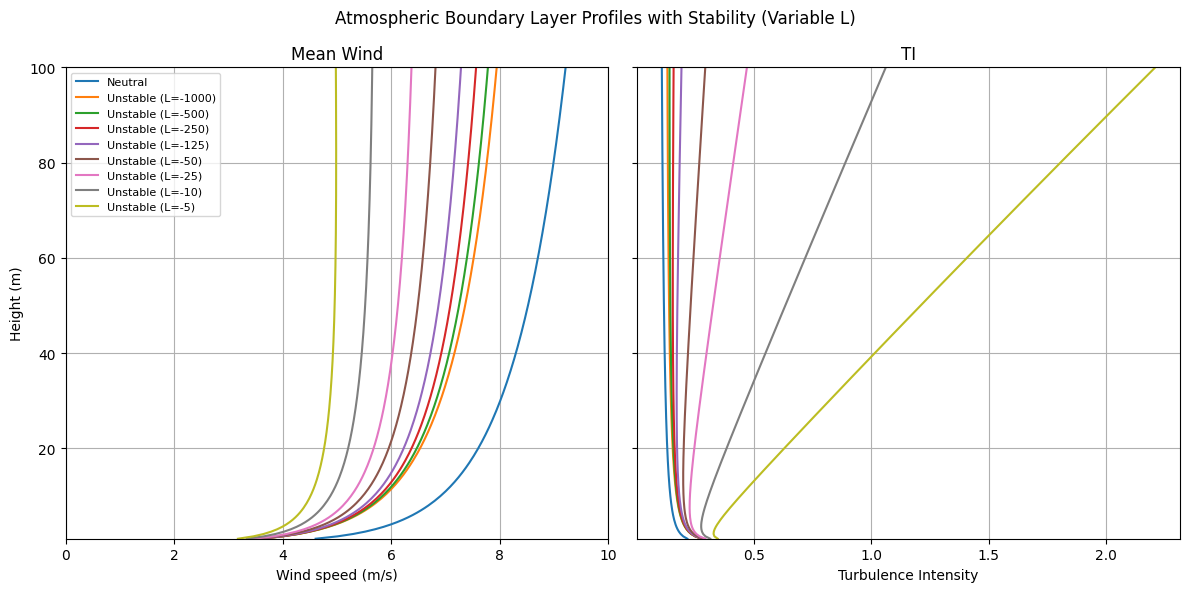

In [185]:
# constants
kappa = 0.4
u_star = 0.4
z0 = 0.01  # roughness values

# Obukhov lengths (stable → neutral → unstable)
L_values = [np.inf, -1000, -500, -250, -125, -50, -25, -10, -5]

# height range
z = np.linspace(1, 100, 200)

# stability correction function (Businger-Dyer)
def psi(z, L):
    if np.isinf(L):  # neutral
        return 0

    if L > 0:  # stable
        return -4.7 * (z / L)

    if L < 0:  # unstable
        return (1 - 16 * (z / L))**0.25
    
# wind profile
def U(z, u_star, z0, L):
    return (u_star / kappa) * (np.log(z / z0) - psi(z, L))

# turbulence intensity components
def sigma_u(u_star, z, L):
    if np.isinf(L):  # neutral
        return 2.5 * u_star
    elif L > 0:  # stable → reduced turbulence
        return 2.5 * u_star * (1 - 0.5 * z / L)
    else:  # unstable → enhanced turbulence
        return 2.5 * u_star * (1 + 0.5 * np.abs(z / L))

def TI(z, u_star, z0, L):
    return sigma_u(u_star, z, L) / U(z, u_star, z0, L)

# plotting
fig, ax = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for L in L_values:
    U_vals = U(z, u_star, z0, L)
    TI_vals = TI(z, u_star, z0, L)

    # label depending on stability
    if np.isinf(L):
        label = "Neutral"
    elif L > 0:
        label = f"Stable (L={L})"
    else:
        label = f"Unstable (L={L})"
    ax[0].plot(U_vals, z, label=f'{label}')
    ax[1].plot(TI_vals, z)

# labels and formatting
ax[0].set_xlabel("Wind speed (m/s)")
ax[0].set_title("Mean Wind")
ax[0].set_xlim(0,10)

ax[1].set_xlabel("Turbulence Intensity")
ax[1].set_title("TI")

ax[0].set_ylabel("Height (m)")

for a in ax:
    a.grid(True)
    a.set_ylim(1, 100)

ax[0].legend(fontsize=8)

plt.suptitle("Atmospheric Boundary Layer Profiles with Stability (Variable L)")
plt.tight_layout()
plt.show()

## Investigating wind speed up over Gaussian hill

### Wind over hill profile comparison plot using <span style="color: gold;">Troen & Petersen speed up model</span>

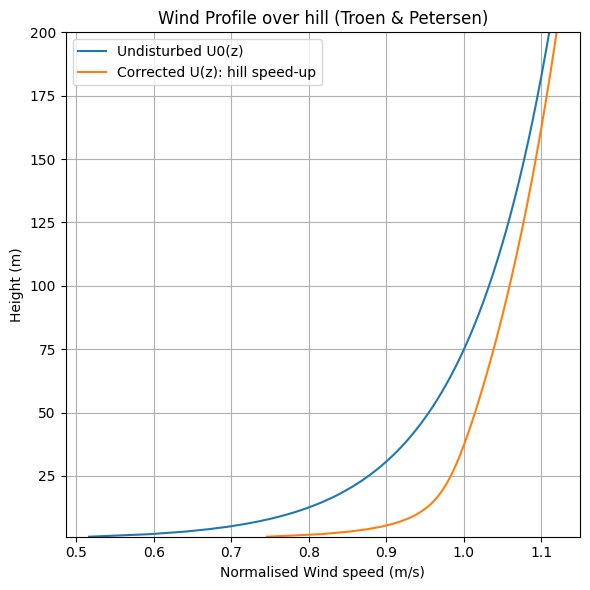

In [186]:
# Source: Understanding Wind Power Technology - Alois Schaffarczyk, 2014, citing work by Troen & Petersen, 1989 
# This model only seems to work at crest and far upstream from hill, but not on the way up/down the hill

# Constants
kappa = 0.4
u_star = 0.4
z0 = 0.01

# Terrain parameters
H = 25       # hill height
sigma = 2*H
L = sigma    # characteristic length

# Undisturbed log profile
def U0(z):
    return (u_star / kappa) * np.log(z / z0)

# Speed‑up factor
def S(z):
        factor1 = 0.5 * H / L
        factor2 = np.log(L/z0) / np.log(z/z0)
        factor3 = 1 / (1 + z/L)**2
        return factor1 * factor2 * factor3

# Corrected wind speed
def U(z):
    return U0(z) * (1 + S(z))

# Heights
z = np.linspace(1, 200, 200)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(U0(z)/U0(z).mean(), z, label='Undisturbed U0(z)')
plt.plot(U(z)/U0(z).mean(), z, label='Corrected U(z): hill speed‑up')
plt.xlabel("Normalised Wind speed (m/s)")
plt.ylabel("Height (m)")
plt.title("Wind Profile over hill (Troen & Petersen)")
plt.grid(True)
plt.ylim(1, 200)
plt.legend()
plt.tight_layout()
plt.show()

### Model implementation: <span style="color: skyblue;">Jackson-Hill speed up model</span>

In [187]:
# -----------------------
# constants
# -----------------------
kappa = 0.4
u_star = 0.4

# terrain parameters
H = 25
sigma = 2 * H

# roughness
z0 = 0.01

# -----------------------
# base log-law profile
# -----------------------
def U0(z, u_star, z0):
    return (u_star / kappa) * np.log(z / z0)

# -----------------------
# Gaussian hill
# -----------------------
def hill(x):
    return H * np.exp(-(x**2) / (2 * sigma**2))

# -----------------------
# Jackson–Hunt parameters
# -----------------------
L = sigma
ell = L / np.log(L / z0)

# -----------------------
# Jackson–Hunt wind model
# -----------------------
def U(x, z):
    base = U0(z, u_star, z0)
    

    speedup = (
        (hill(x) / L)
        * (np.log(L / z0)**2)
        / (np.log(z / z0) * np.log(ell / z0))
    )
    
    # keep it physical
    speedup = np.clip(speedup, -0.5, 1.0)
    
    return base * (1 + speedup)

### Wind over hill profile comparison plot using <span style="color: skyblue;">Jackson-Hill speed up model</span> 

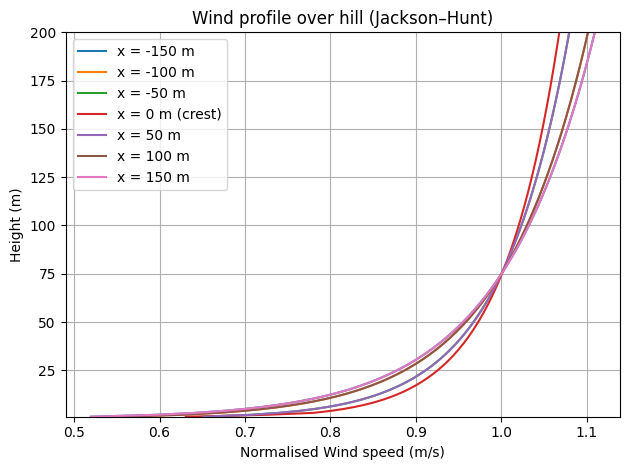

In [188]:
# -----------------------
# domains
# -----------------------
z = np.linspace(1, 200, 200)

# sample positions
x_positions = [-150, -100, -50, 0, 50, 100, 150]

# -----------------------
# plotting
# -----------------------
plt.plot(figsize=(6, 6))

for x in x_positions:
    U_vals = U(x, z)

    label = f"x = {x} m"
    if x == 0:
        label += " (crest)"

    plt.plot(U_vals/U_vals.mean(), z, label=label)

# labels
plt.xlabel("Normalised Wind speed (m/s)")
plt.ylabel("Height (m)")
plt.title("Wind profile over hill (Jackson–Hunt)")
plt.grid(True)
plt.ylim(1, 200)
plt.legend()
plt.tight_layout()
plt.show()

### Wind over hill profile visualisation using <span style="color: skyblue;">Jackson-Hill speed up model</span>

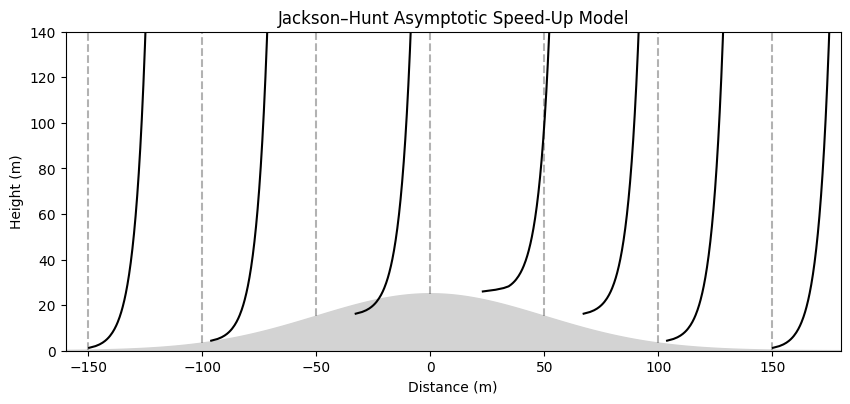

In [189]:
# to make the change in profile more visible
scale = 5 

# domain
x = np.linspace(-200, 200, 512)
z = np.linspace(1, 150, 200)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10, 6))

# plot hill
plt.fill_between(x, hill(x), color="lightgray")

positions = [-150, -100, -50, 0, 50, 100, 150]

for x0 in positions:
    idx = np.argmin(np.abs(x - x0))
    
    U_vals = U(x0, z)
    
    # horizontal displacement
    x_profile = x0 + (U_vals - U0(z[0],u_star,z0)) * scale
    
    # vertical shift by terrain
    z_profile = z + hill(x)[idx]
    
    plt.plot(x_profile, z_profile, color='k')
    
    # reference vertical line
    plt.plot([x0, x0], [hill(x)[idx], hill(x)[idx] + 150],
             linestyle="--", color="k", alpha=0.3)

plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.xlim(-160, 180)
plt.ylim(0, 140)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Jackson–Hunt Asymptotic Speed-Up Model")

plt.show()

### Model implementation: <span style="color: lightgreen;">ChatGPT speed up model</span>

In [190]:

# -----------------------
# constants
# -----------------------
kappa = 0.4
u_star = 0.4
z0 = 0.01
# terrain parameters
H = 25
sigma = 2 * H
L = sigma   # characteristic length


# Troen & Petersen coefficient
A = 0.5  # typical range: 1.5–4

# -----------------------
# base log-law profile
# -----------------------
def U0(z):
    return (u_star / kappa) * np.log(z / z0)

# -----------------------
# Gaussian hill
# -----------------------
def hill(x):
    return H * np.exp(-(x**2) / (2 * sigma**2))

# -----------------------
# Troen & Petersen model
# -----------------------
def U(x, z):
    base = U0(z)
    
    # horizontal shape (normalized hill)
    f = hill(x) / H
    
    # vertical decay
    g = np.exp(-z / L)
    
    speedup = A * (H / L) * f * g
    
    return base * (1 + speedup)


### Wind over hill profile comparison plot using <span style="color: lightgreen;">ChatGPT speed up model</span>

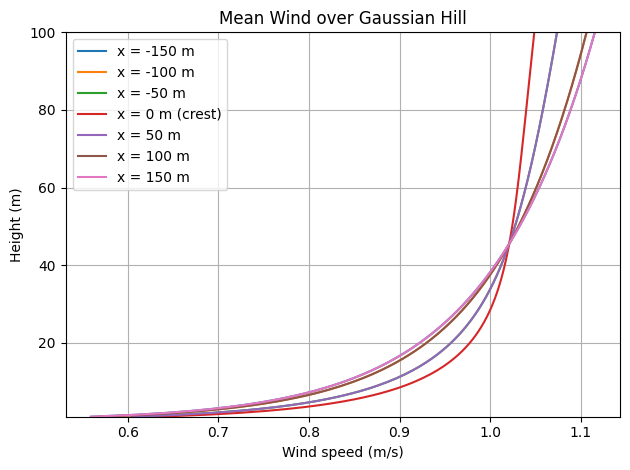

In [191]:
# domain of z
z = np.linspace(1, 100, 200)

# sample positions
x_positions = [-150, -100, -50, 0, 50, 100, 150]

plt.plot(figsize=(12, 6))

for x in x_positions:
    U_vals = U(x, z)
    label = f"x = {x} m"
    if x == 0:
        label += " (crest)"
    plt.plot(U_vals/U_vals.mean(), z, label=label)

# visualisation config
plt.xlabel("Wind speed (m/s)")
plt.ylabel("Height (m)")
plt.title("Mean Wind over Gaussian Hill")
plt.grid(True)
plt.ylim(1, 100)
plt.legend()
plt.tight_layout()
plt.show()

### Wind over hill profile visualisation using <span style="color: lightgreen;">ChatGPT speed up model</span>

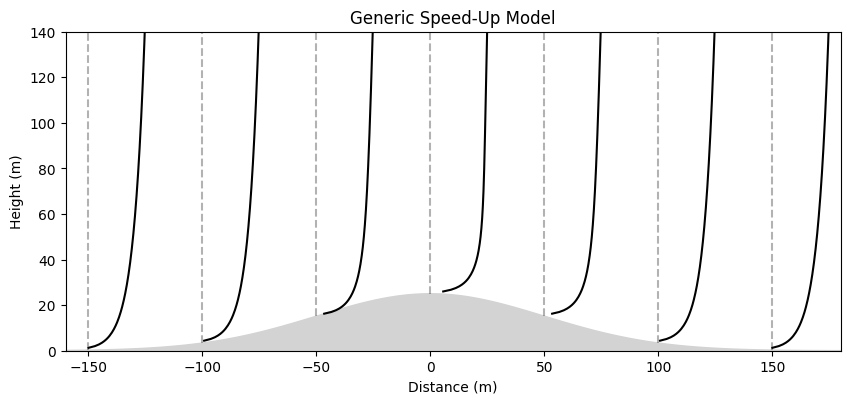

In [192]:
# to make the change in profile more visible
scale = 5 

# domain
x = np.linspace(-200, 200, 512)
z = np.linspace(1, 150, 200)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(10, 6))

# plot hill
plt.fill_between(x, hill(x), color="lightgray")

positions = [-150, -100, -50, 0, 50, 100, 150]

for x0 in positions:
    idx = np.argmin(np.abs(x - x0))
    
    U_vals = U(x0, z)
    
    # horizontal displacement
    x_profile = x0 + (U_vals - U0(z[0])) * scale
    
    # vertical shift by terrain
    z_profile = z + hill(x)[idx]
    
    plt.plot(x_profile, z_profile, color='k')
    
    # reference vertical line
    plt.plot([x0, x0], [hill(x)[idx], hill(x)[idx] + 150],
             linestyle="--", color="k", alpha=0.3)

plt.xlabel("Distance (m)")
plt.ylabel("Height (m)")
plt.xlim(-160, 180)
plt.ylim(0, 140)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("Generic Speed-Up Model")

plt.show()